# Solution for exercise 8.8
***

In [ ]:
#Importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

In [17]:
#Loading data
Carseats = load_data('Carseats')
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## a)
***

In [18]:
#Split data 50/50
np.random.seed(123)
train, test = train_test_split(Carseats, test_size = 0.5, random_state = 123)

X_train = pd.get_dummies(train.drop(columns = 'Sales'), drop_first = True)
y_train = train['Sales']
X_test = pd.get_dummies(test.drop(columns = 'Sales'), drop_first = True)
y_test = test['Sales']

## b)
***

In [19]:
#Regression tree
tree = DecisionTreeRegressor(min_samples_leaf = 30, random_state = 123)
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max

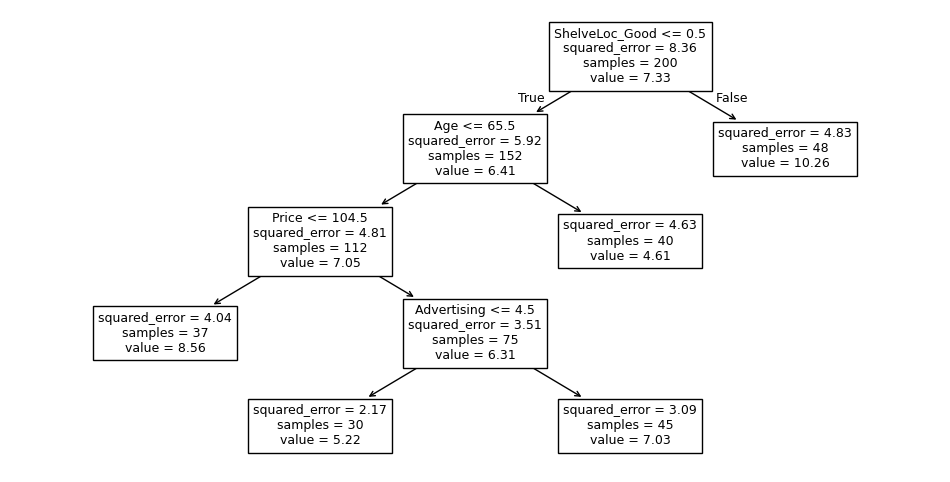

In [22]:
#Plot
fig, ax = plt.subplots(figsize = (12, 6))
plot_tree(tree, feature_names = X_train.columns, precision = 2, fontsize = 9, ax = ax)
plt.show()

In [27]:
#MSE
MSE_b = mean_squared_error(y_test, tree.predict(X_test))
print(f"Test MSE (b): {MSE_b:.4f}")

Test MSE (b): 6.6492


## c)
***

In [33]:
#Cross-validation
big_tree = DecisionTreeRegressor(min_samples_leaf = 2, random_state = 0)
big_tree.fit(X_train, y_train)

path = big_tree.cost_complexity_pruning_path(X_train, y_train)
kfold = KFold(5, shuffle = True, random_state = 10)
grid = GridSearchCV(big_tree, {"ccp_alpha" : path.ccp_alphas}, refit = True, cv = kfold, scoring = "neg_mean_squared_error")
grid.fit(X_train, y_train)

pruned = grid.best_estimator_

MSE_c = mean_squared_error(y_test, pruned.predict(X_test))
print(f"Test MSE (pruned): {MSE_c:.4f}")
print(f"Best alpha: {grid.best_params_['ccp_alpha']:.4f}")

Test MSE (pruned): 5.9601
Best alpha: 0.1198


## d)
***

In [36]:
#Bagging
p = X_train.shape[1]
bag = RandomForestRegressor(max_features = p, n_estimators = 100, random_state = 123)
bag.fit(X_train, y_train)

MSE_d = mean_squared_error(y_test, bag.predict(X_test))
print(f"Test MSE (bagging): {MSE_d:.4f}")

pd.DataFrame({"importance" : bag.feature_importances_}, index = X_train.columns).sort_values("importance", ascending = False)

Test MSE (bagging): 3.0855


,importance
ShelveLoc_Good,0.322893
Price,0.220007
Age,0.109154
CompPrice,0.085111
Advertising,0.071912
ShelveLoc_Medium,0.061223
Income,0.051875
Education,0.034966
Population,0.033362
Urban_Yes,0.005644


## e)
---

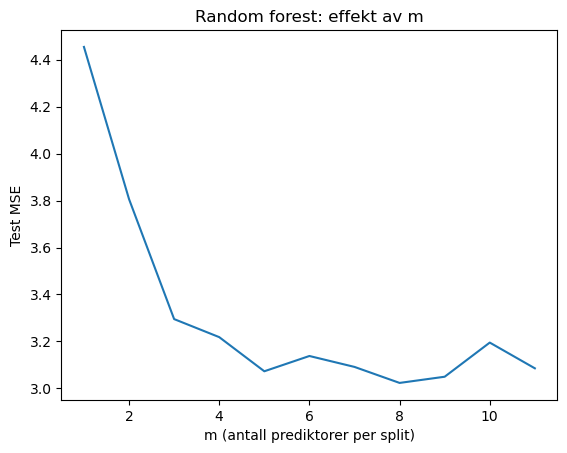

Beste m: 8, Test MSE: 3.023


,importance
ShelveLoc_Good,0.302091
Price,0.219765
Age,0.112861
Advertising,0.084883
CompPrice,0.081211
Income,0.058336
ShelveLoc_Medium,0.053206
Population,0.038223
Education,0.036022
Urban_Yes,0.006899


In [37]:
#Random forests + effect of m
m_values = range(1, p + 1)
mse_rf = [mean_squared_error(y_test,
           RandomForestRegressor(max_features=m, n_estimators=100, random_state=123)
           .fit(X_train, y_train).predict(X_test))
          for m in m_values]

plt.plot(list(m_values), mse_rf)
plt.xlabel("m (antall prediktorer per split)")
plt.ylabel("Test MSE")
plt.title("Random forest: effekt av m")
plt.show()

best_m = list(m_values)[np.argmin(mse_rf)]
print(f"Beste m: {best_m}, Test MSE: {min(mse_rf):.3f}")

rf_best = RandomForestRegressor(max_features=best_m, n_estimators=100, random_state=123)
rf_best.fit(X_train, y_train)
pd.DataFrame({"importance": rf_best.feature_importances_},
             index=X_train.columns).sort_values("importance", ascending=False)


## f)
***